In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
Swst = math.pi*12**2
Swst=math.pi*12**2 #wst is a 12 meters

Swst=math.pi*12**2 #wst is a 12 meters

def t_tel(m,t1exp=15,eta=1.2,Stel=Swst,SNR=10,tref=2*60, mref=24.5, SNRref=10):

    def I(m):#flux as function of magnitude. To be checked.
        I0=1# anyway we will consider ratio of flux
        return I0*10**(-0.4*m)
    
    Sdesi=math.pi*4**2 #desi is a 4 meter
    

    x=tref/t1exp *Sdesi/Stel*(I(mref)*SNR/(eta*I(m)*SNRref))**2
    
    return np.array([x_*t1exp for x_ in x]) #ceil is partie entiere sup


In [2]:
SNR_desi_delta = 0.5 
dlambda_desi = 0.8 #resolution of the DESI spectrograph
dLambda = 1370 #size of the r-filter
SNR_desi_Delta = SNR_desi_delta * np.sqrt(dLambda/dlambda_desi)

<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_546868/3224851867.py:32: SyntaxWarning: invalid escape sequence '\l'
  363.21218689082974], '--x', color='k', markersize=10,label = f'WST ETC (uniform in $\lambda$, point source)'


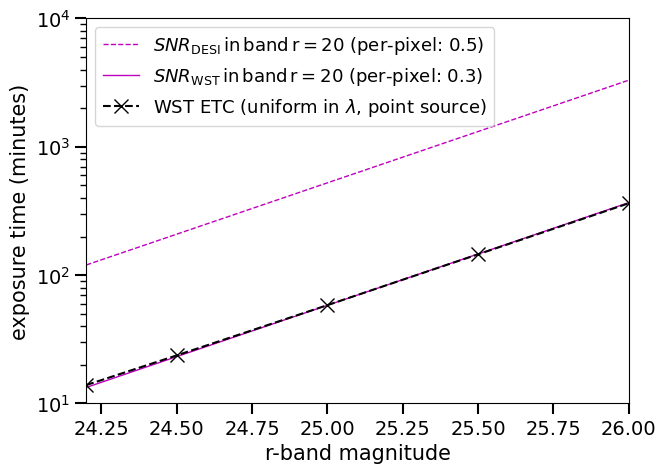

In [4]:
m = np.linspace(24.2, 26, 10)

plt.figure(figsize=(7,5))
plt.plot(m, t_tel(m,t1exp=15,eta=1,Stel=math.pi*4**2,SNR=20,
                  tref=2*60, mref=24.2, SNRref=20),
         '--m',
         label=r'$SNR_{\rm DESI}\, {\rm in\, band\, r} = 20$'
         + f' (per-pixel: {(20/np.sqrt(dLambda/dlambda_desi)):.1f})', lw=1)

plt.plot(m, t_tel(m,t1exp=15,eta=1,Stel=Swst,SNR=20,
                  tref=2*60, mref=24.2, SNRref=20),
         'm',
         label=r'$SNR_{\rm WST}\, {\rm in\, band\, r} = 20$'
         + f' (per-pixel: {(20/np.sqrt(dLambda/dlambda_desi * (7/3))):.1f})', lw=1)

plt.ylabel('exposure time (minutes)', fontsize=15)
plt.xlabel('r-band magnitude', fontsize=15)

# Bigger ticks ("sticks")
plt.tick_params(axis='both', which='major',
                labelsize=14, length=8, width=1.5)
plt.tick_params(axis='both', which='minor',
                length=4, width=1)
plt.ylim(10, 10000)
plt.xlim(m[0], m[-1])

plt.plot([24.2, 24.5, 25, 25.5, 26],
         [13.912506791313808,
 23.69199000227998,
 58.386438821752066,
 145.28295308674163,
 363.21218689082974], '--x', color='k', markersize=10,label = f'WST ETC (uniform in $\lambda$, point source)'
        )
plt.legend(fontsize=13)
plt.yscale('log')
#plt.savefig(f'../figures/wst_etc_t_vs_m.png', dpi = 300, bbox_inches='tight' )